# Predicting Student Performance in Mathematics

**Course:** Data Mining, Fall 2026
**Team:** Aleida Ramirez, Bidhan Khadka
**Date:** September 2026

---

## Problem Statement
Schools collect a large amount of data about their students. This project uses that data to **predict a student's final
mathematics grade (G3, on a 0–20 scale)** from attributes such as attendance, study time, past failures, family
background and earlier exam scores. Accurate predictions could help teachers identify students who need support.

This is a **regression** problem: the target is a number, not a category.

## Dataset
- **Source:** UCI Machine Learning Repository, *Student Performance* dataset (Cortez & Silva, 2008):
  https://archive.ics.uci.edu/ml/datasets/Student+Performance
- **File used:** `student-mat.csv` (Mathematics course, two Portuguese secondary schools)
- **Size:** 395 students × 33 attributes
- **Target:** `G3`, the final-period grade (0–20)
- **Features:** school, demographics, family background, study habits, social life, and the earlier period grades
  `G1` (1st period) and `G2` (2nd period)

## Approach
1. **Exploratory data analysis:** descriptive statistics and visualizations of the grades and their relationships.
2. **Data preprocessing:** encoding of categorical variables, a scaling strategy, and correlation-based feature importance.
3. **Model training:** Linear Regression and Random Forest, trained with an 80/20 train/test split, each on two feature
   sets (with and without the earlier grades G1/G2).
4. **Evaluation:** MSE and R² on the test set, 5-fold cross-validation, model-based feature importance and
   Actual vs. Predicted plots.

## Contents
1. Setup
2. Data Loading
3. Exploratory Data Analysis
4. Data Preprocessing
5. Model Training
6. Model Evaluation
7. Model Performance Visualization
8. Discussion of Results
9. Challenges
10. Conclusion
11. References

**Reproducibility:** run all cells from top to bottom (*Restart & Run All*). All randomness uses `RANDOM_STATE = 42`, and
library versions are listed in `requirements.txt`.

## 1. Setup
Import the libraries used for data handling and visualization, fix the random seed so results can be reproduced, and
define one consistent plot style and color palette for the exploratory figures.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42  # use the same seed as Part B

# Consistent plot style for every figure
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3})
BLUE, ORANGE, GREEN, RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'

## 2. Data Loading
The original UCI file uses `;` as its separator. `sep=None` lets pandas detect the separator automatically, so the
notebook also works with a comma-separated copy of the file. We then check the shape, data types, missing values and
duplicate rows.

In [2]:
# Load the dataset
# The original UCI file uses ';' as separator. sep=None lets pandas detect it,
# so this also works if someone uses a comma-separated copy of the file.
df = pd.read_csv("student-mat.csv", sep=None, engine="python")

In [3]:
# Shape, head, info
print("Shape:", df.shape)   # expected (395, 33)
df.info()
df.head()

Shape: (395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    objec

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# Check for missing values
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


**Observations:**

- The dataset has **395 students and 33 columns**, as expected.
- **16 columns are numeric** (age, grades, 1–5 ratings, counts) and **17 are text/categorical** (school, sex, parents' jobs, yes/no answers).
- There are **no missing values and no duplicate rows**, so no rows need to be dropped or filled.

## 3. Exploratory Data Analysis

### 3.1 Descriptive Statistics
Mean, median and standard deviation (plus minimum and maximum) of the key numerical features: `age`, `absences`,
`studytime`, `failures` and the three period grades `G1`, `G2`, `G3`.

In [5]:
# Descriptive statistics (mean, median, std)
key_features = ["age", "absences", "studytime", "failures", "G1", "G2", "G3"]
desc = df[key_features].agg(["mean", "median", "std", "min", "max"]).T.round(2)
desc

,mean,median,std,min,max
age,16.70,17.0,1.28,15.0,22.0
absences,5.71,4.0,8.00,0.0,75.0
studytime,2.04,2.0,0.84,1.0,4.0
failures,0.33,0.0,0.74,0.0,3.0
G1,10.91,11.0,3.32,3.0,19.0
G2,10.71,11.0,3.76,0.0,19.0
G3,10.42,11.0,4.58,0.0,20.0


**Observations:**

- **Grades** average about 10.5 out of 20 (G1 = 10.91, G2 = 10.71, G3 = 10.42). G3 has the widest spread (std = 4.58).
- G3's **mean (10.42) is below its median (11)** — a group of zero grades pulls the average down (see the histogram below).
- **Absences** are right-skewed: median 4 and mean 5.71, but the maximum is 75.
- Most students have **0 past failures** (median 0, mean 0.33) and study **2–5 hours a week** (studytime median 2).
- Students are **15–22 years old**, mostly 16–17 (mean 16.7).

### 3.2 Distribution of the Final Grade (G3)
A histogram of the target variable, with its mean and median marked and the students who received a final grade of 0
highlighted.

Students with G3 = 0: 38 (9.6%)


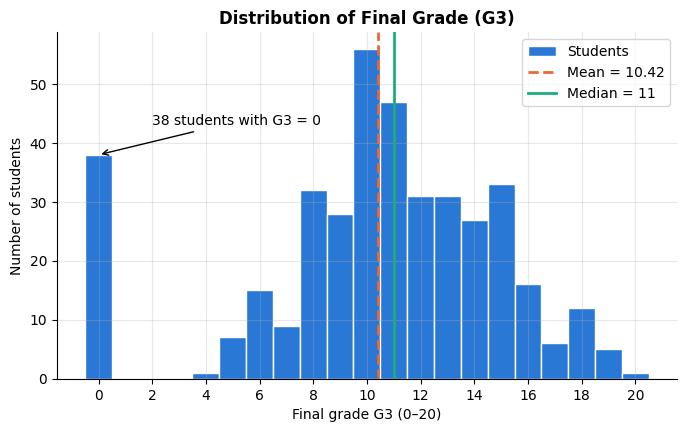

In [6]:
# Histogram of G3
n_zero = (df["G3"] == 0).sum()
print(f"Students with G3 = 0: {n_zero} ({n_zero / len(df):.1%})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["G3"], bins=np.arange(-0.5, 21.5, 1), color=BLUE, edgecolor="white", label="Students")
ax.axvline(df["G3"].mean(), color=ORANGE, ls="--", lw=2, label=f"Mean = {df['G3'].mean():.2f}")
ax.axvline(df["G3"].median(), color=GREEN, lw=2, label=f"Median = {df['G3'].median():.0f}")
ax.annotate(f"{n_zero} students with G3 = 0", xy=(0, n_zero), xytext=(2, n_zero + 5),
            arrowprops=dict(arrowstyle="->"))
ax.set_title("Distribution of Final Grade (G3)")
ax.set_xlabel("Final grade G3 (0–20)")
ax.set_ylabel("Number of students")
ax.set_xticks(range(0, 21, 2))
ax.legend()
plt.show()

**Observations:**

- Apart from zeros, G3 is **roughly bell-shaped**, with most grades between 8 and 15.
- **38 students (9.6%) have G3 = 0.** No one scored 1–3, so these zeros are separated from the rest of the distribution.
- All 38 of these students have **0 recorded absences**, and 13 already had G2 = 0. This suggests they **dropped the course or skipped the final exam** rather than truly scoring zero. These students will be the hardest for any model to predict.

### 3.3 Correlation Heatmap of Numeric Features
Pearson correlation between every pair of numeric features (lower triangle shown). Values near +1 or −1 indicate a
strong linear relationship, and values near 0 indicate little or none.

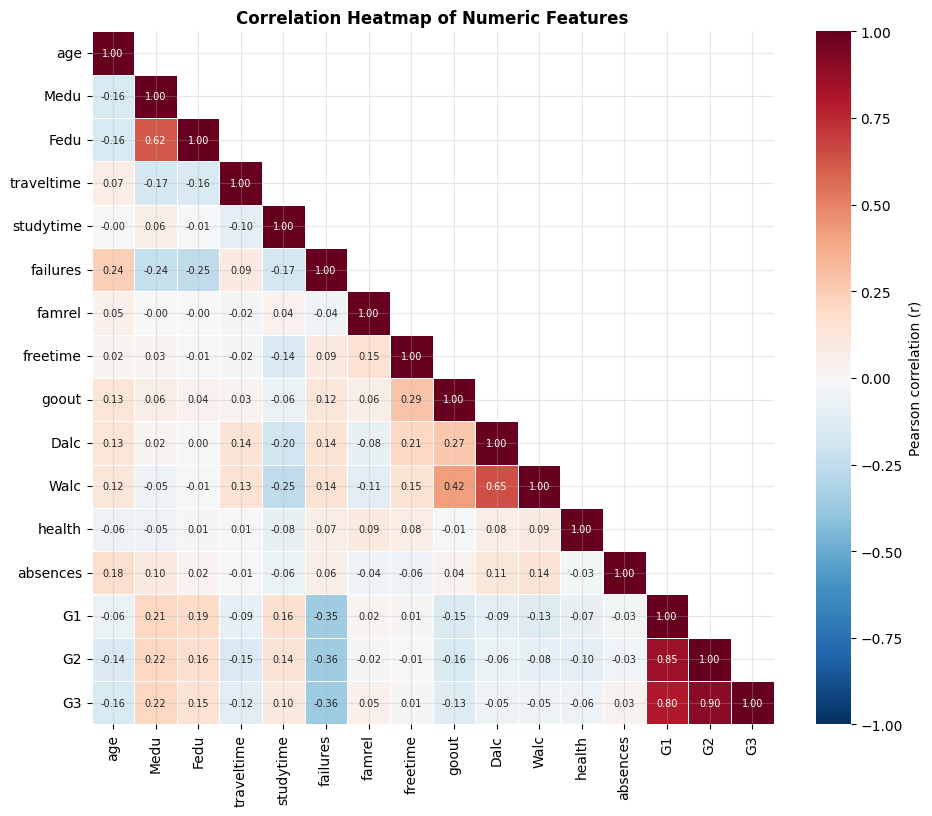

In [7]:
# Correlation heatmap
num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, linewidths=0.5, cbar_kws={"label": "Pearson correlation (r)"}, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.show()

**Observations:**

- **G2 (r = 0.90) and G1 (r = 0.80)** have by far the strongest correlation with G3. Earlier grades are the best predictor of the final grade.
- G1 and G2 are also strongly correlated with each other (r = 0.85), so they carry overlapping information.
- **Failures** is the strongest non-grade feature (r = −0.36): more past failures → lower final grade.
- **Mother's education** (r = 0.22) and **father's education** (r = 0.15) are mildly positive; **age, going out and travel time** are mildly negative.
- Weekday and weekend alcohol use (Dalc, Walc) correlate with each other (r = 0.65) but barely with G3. Absences have almost no linear relationship with G3 (r = 0.03).

### 3.4 Final Grade by Study Time and by Past Failures
Box plots show how the distribution of G3 changes across study-time levels and numbers of past class failures. The
number of students in each group is shown above its box.

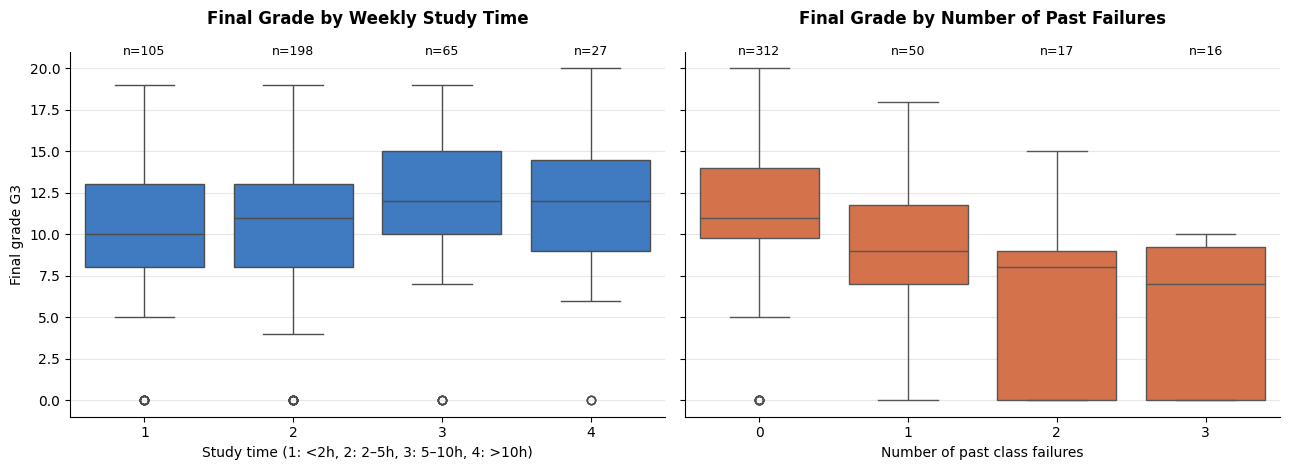

           count  median   mean
studytime                      
1            105    10.0  10.05
2            198    11.0  10.17
3             65    12.0  11.40
4             27    12.0  11.26
          count  median   mean
failures                      
0           312    11.0  11.25
1            50     9.0   8.12
2            17     8.0   6.24
3            16     7.0   5.69


In [8]:
# Box plot(s)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

sns.boxplot(data=df, x="studytime", y="G3", color=BLUE, ax=axes[0])
axes[0].set_title("Final Grade by Weekly Study Time", pad=20)
axes[0].set_xlabel("Study time (1: <2h, 2: 2–5h, 3: 5–10h, 4: >10h)")
axes[0].set_ylabel("Final grade G3")

sns.boxplot(data=df, x="failures", y="G3", color=ORANGE, ax=axes[1])
axes[1].set_title("Final Grade by Number of Past Failures", pad=20)
axes[1].set_xlabel("Number of past class failures")
axes[1].set_ylabel("Final grade G3")

# Show group sizes above each box
for ax, col in zip(axes, ["studytime", "failures"]):
    for i, n in enumerate(df[col].value_counts().sort_index()):
        ax.text(i, 20.8, f"n={n}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(df.groupby("studytime")["G3"].agg(["count", "median", "mean"]).round(2))
print(df.groupby("failures")["G3"].agg(["count", "median", "mean"]).round(2))

**Observations:**

- **Study time:** median G3 rises from 10 (<2 hours/week) to 12 (5+ hours/week), but the boxes overlap a lot. Study time has only a weak effect (r = 0.10).
- **Failures:** median G3 drops steadily from 11 (0 failures) to 9, 8 and 7 (1, 2, 3 failures). This is a much clearer pattern.
- Groups with more failures are small (only 17 and 16 students with 2 and 3 failures), so their boxes are less reliable.
- Zero-grade outliers appear in every group, showing that dropping out is not limited to one type of student.

### 3.5 Second-Period Grade (G2) vs. Final Grade (G3)
A scatter plot of the strongest relationship in the dataset. Students with a final grade of 0 are shown in red, and the
dashed line marks G3 = G2 (no change between periods).

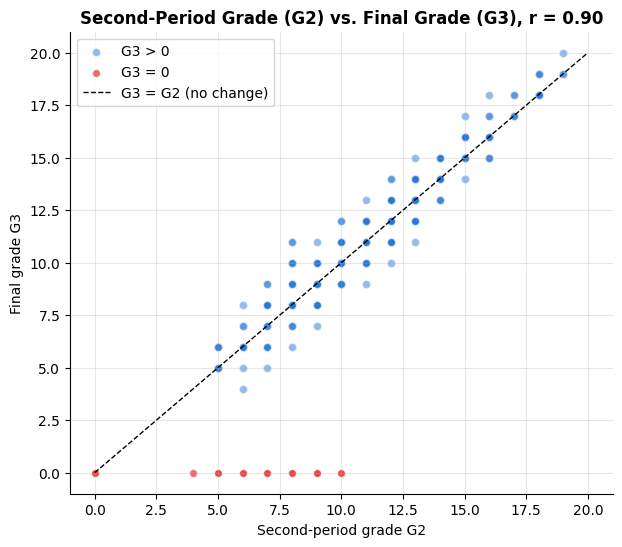

In [9]:
# Scatter plot
zero = df["G3"] == 0
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df.loc[~zero, "G2"], df.loc[~zero, "G3"], color=BLUE, alpha=0.5, edgecolor="white", label="G3 > 0")
ax.scatter(df.loc[zero, "G2"], df.loc[zero, "G3"], color=RED, alpha=0.8, edgecolor="white", label="G3 = 0")
ax.plot([0, 20], [0, 20], "k--", lw=1, label="G3 = G2 (no change)")
ax.set_title(f"Second-Period Grade (G2) vs. Final Grade (G3), r = {df['G2'].corr(df['G3']):.2f}")
ax.set_xlabel("Second-period grade G2")
ax.set_ylabel("Final grade G3")
ax.legend()
plt.show()

**Observations:**

- For almost all students, G3 is **very close to G2**: the points lie along the diagonal. This explains the r = 0.90 correlation.
- The **red points** are students with G2 between 4 and 10 but a final grade of 0. They break the straight-line pattern and will cause the largest prediction errors.
- Because G2 is so predictive, a model with G1/G2 will score high. A model without them shows how well background features alone can predict grades.

## 4. Data Preprocessing

### 4.1 Categorical vs. Numerical Columns
Separate the text (categorical) columns, which must be encoded, from the numerical ones, and count the categories in each
text column.

In [10]:
# Identify column types
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
numerical_cols = df.select_dtypes(include="number").columns.tolist()

print(f"Categorical ({len(categorical_cols)}):", categorical_cols)
print(f"Numerical ({len(numerical_cols)}):", numerical_cols)

# How many categories each text column has
df[categorical_cols].nunique().sort_values()

Categorical (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical (16): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


school        2
higher        2
nursery       2
activities    2
paid          2
famsup        2
schoolsup     2
internet      2
romantic      2
Pstatus       2
famsize       2
address       2
sex           2
guardian      3
reason        4
Fjob          5
Mjob          5
dtype: int64

### 4.2 Encoding Categorical Variables
The categorical columns are one-hot encoded with `pd.get_dummies(..., drop_first=True)`.

**Why is this necessary?**
- **ML models need numeric input.** scikit-learn cannot use text values like `"GP"` or `"teacher"` directly.
- **One-hot avoids implying a false order.** Numbering parents' jobs as 0, 1, 2, 3 would tell the model that "teacher" is somehow "more" than "at_home". One-hot gives each category its own 0/1 column instead.
- **`drop_first=True` avoids redundant columns.** If a student isn't in any of the other job categories, the dropped one is implied. Keeping all of them would make the columns perfectly collinear (the "dummy variable trap"), which breaks Linear Regression.
- 13 of the 17 categorical columns have only 2 values (e.g. yes/no), so each becomes a single 0/1 column. The 4 multi-category columns (`Mjob`, `Fjob`, `reason`, `guardian`) become several columns.
- **Numeric columns are left as they are.** `Medu`, `Fedu` and the 1–5 ratings are already numbers where the order matters (e.g. more education = higher number).

In [11]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("Before encoding:", df.shape)
print("After encoding: ", df_encoded.shape)   # 33 columns -> 42 (41 features + G3)
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(f"New dummy columns ({len(new_cols)}):", new_cols)
assert df_encoded.isnull().sum().sum() == 0
df_encoded.head()

Before encoding: (395, 33)
After encoding:  (395, 42)
New dummy columns (26): ['school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


### 4.3 Normalization / Standardization
The actual scaling is applied in Section 5.4, **after** the train/test split, to avoid data leakage.

**Why?**
- **Linear Regression:** features are on very different scales (absences 0–75, grades 0–20, dummy columns 0–1). Without scaling, the size of each coefficient depends on the unit of the feature, so they can't be compared fairly. → use `StandardScaler` (mean 0, standard deviation 1).
- **Decision Tree / Random Forest:** they split on thresholds (e.g. "G2 ≤ 9.5"), so scaling doesn't change the result → scaling not required.
- **Why scale after the split:** the scaler must learn the mean and std from the **training set only**. Scaling before the split would let information from the test set leak into training and make results look better than they really are.
- The cell below only **demonstrates** what scaling does on a copy; the processed data is saved **unscaled**.

In [12]:
# (Optional) demonstrate StandardScaler on a copy of the numeric features
demo_cols = ["age", "absences", "studytime", "G1", "G2"]
scaled_demo = pd.DataFrame(StandardScaler().fit_transform(df[demo_cols]), columns=demo_cols)

comparison = pd.DataFrame({
    "original mean": df[demo_cols].mean(), "original std": df[demo_cols].std(),
    "scaled mean": scaled_demo.mean(), "scaled std": scaled_demo.std(ddof=0),
}).round(2)
comparison

,original mean,original std,scaled mean,scaled std
age,16.70,1.28,0.0,1.0
absences,5.71,8.00,-0.0,1.0
studytime,2.04,0.84,-0.0,1.0
G1,10.91,3.32,0.0,1.0
G2,10.71,3.76,-0.0,1.0


### 4.4 Feature Importance: Correlation Analysis
Correlation of every encoded feature with G3, sorted by strength. This is the first of two feature-importance methods;
model-based importance from the Random Forest follows in Section 6.3.

In [13]:
# Correlation with G3 (sorted)
corr_with_g3 = df_encoded.corr()["G3"].drop("G3")
corr_sorted = corr_with_g3.reindex(corr_with_g3.abs().sort_values(ascending=False).index)
corr_sorted.round(3).to_frame("r with G3").head(15)

,r with G3
G2,0.905
G1,0.801
failures,-0.360
Medu,0.217
higher_yes,0.182
age,-0.162
Fedu,0.152
goout,-0.133
romantic_yes,-0.130
traveltime,-0.117


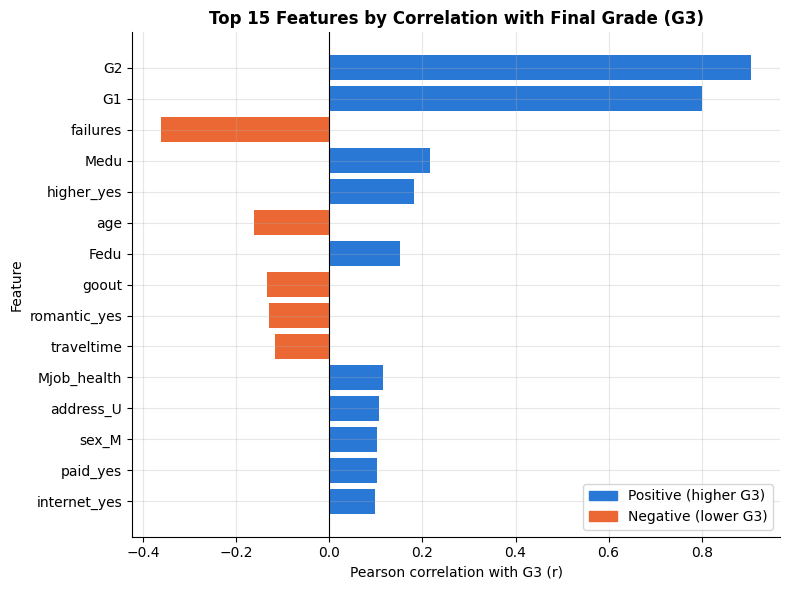

In [14]:
# Bar chart of correlations
top = corr_sorted.head(15)[::-1]   # top 15 by absolute value, strongest at the top
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top.index, top.values, color=[BLUE if v > 0 else ORANGE for v in top.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 15 Features by Correlation with Final Grade (G3)")
ax.set_xlabel("Pearson correlation with G3 (r)")
ax.set_ylabel("Feature")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="Positive (higher G3)"),
                   Patch(color=ORANGE, label="Negative (lower G3)")], loc="lower right")
plt.tight_layout()
plt.show()

**Observations:**

- **G2 (0.90) and G1 (0.80)** dominate. Every other feature has |r| below 0.4.
- **Failures (−0.36)** is the strongest non-grade predictor, followed by **mother's education (0.22)**, **wanting higher education (`higher_yes`, 0.18)**, **age (−0.16)** and **father's education (0.15)**.
- Going out, being in a relationship (`romantic_yes`) and longer travel time are linked to slightly lower grades; urban address (`address_U`) and a mother working in health are linked to slightly higher grades.
- Correlation only measures **straight-line** relationships. A feature like absences (r ≈ 0.03) could still matter to a tree model in a non-linear way. The Random Forest importance in Section 6.3 checks this.

### 4.5 Saving the Processed Data
The encoded (unscaled) dataset is saved to `processed_data.csv`, which the modeling section loads.

In [15]:
# Save the encoded (unscaled) data so Part B can load it
df_encoded.to_csv("processed_data.csv", index=False)
print("Saved processed_data.csv:", df_encoded.shape)

# Quick check that it reloads correctly
check = pd.read_csv("processed_data.csv")
assert check.shape == df_encoded.shape and check.isnull().sum().sum() == 0
print("Reload check passed.")

Saved processed_data.csv: (395, 42)
Reload check passed.


### 4.6 Summary of EDA and Preprocessing
- **Earlier grades drive the final grade:** G2 (r = 0.90) and G1 (r = 0.80) are by far the strongest predictors; all other features have |r| < 0.4.
- **38 students (9.6%) have G3 = 0**, all with 0 absences: likely dropouts or students who skipped the final exam. They break the G2 → G3 pattern and will cause the largest prediction errors.
- **Past failures is the strongest non-grade signal** (r = −0.36; median G3 drops from 11 to 7 as failures go from 0 to 3). Parents' education and wanting higher education help slightly; study time has only a weak effect.
- **Preprocessing steps taken and why:**
  - Checked quality: 395 × 33, no missing values or duplicates → nothing to drop or fill.
  - One-hot encoded 17 categorical columns with `drop_first=True` → 42 numeric columns (41 features + G3). Models need numbers; one-hot avoids a false order; drop_first avoids the dummy trap.
  - Scaling: `StandardScaler` for Linear Regression, applied **after** the train/test split (Section 5.4) to avoid data leakage; not needed for tree models.
  - Saved `processed_data.csv` for the modeling stage.

## 5. Model Training

### 5.1 Modeling Setup
Import the scikit-learn tools for splitting, scaling, modeling and evaluation. The plot style from Section 1 is reset to
matplotlib's defaults first, and the modeling figures then use seaborn's `whitegrid` theme.

In [16]:
# Reset the EDA plot style from Section 1 so the modeling figures use their own theme
plt.rcdefaults()

In [17]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42  # same seed as Part A -> reproducible results
sns.set_theme(style="whitegrid")

### 5.2 Loading the Processed Data
Load the encoded data saved in Section 4.5. If that file is missing (for example, when the modeling section is run on
its own), the cell falls back to loading the raw `student-mat.csv` and applying the same one-hot encoding.

In [18]:
# Load processed data (from Part A) or fall back to raw data + one-hot encoding
if os.path.exists("processed_data.csv"):
    df = pd.read_csv("processed_data.csv")
    print("Loaded processed_data.csv from Part A")
else:
    raw = pd.read_csv("student-mat.csv", sep=";")  # file is semicolon-separated
    # Convert categorical (text) columns to 0/1 dummy columns; drop_first avoids redundant columns
    df = pd.get_dummies(raw, drop_first=True, dtype=int)
    print("processed_data.csv not found -> loaded student-mat.csv and one-hot encoded it")

print("Shape:", df.shape)
df.head()

Loaded processed_data.csv from Part A
Shape: (395, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


### 5.3 Features, Target and the Two Feature Sets
- **Target:** `G3`, the final grade.
- **Feature set 1 (with G1/G2):** all 41 features, including the 1st and 2nd period grades. This represents predicting
  the final grade **during** the school year.
- **Feature set 2 (without G1/G2):** 39 features, with only background and behavioral factors. This represents predicting
  **before** the year starts (an early-warning setting).

G1/G2 are very strongly correlated with G3 (Section 3.3), so comparing both sets shows how much the models depend on
them.

In [19]:
# Target variable: final grade G3 (0-20)
y = df["G3"]

# Set 1: every feature except the target (includes period grades G1, G2)
X_with = df.drop(columns=["G3"])

# Set 2: also remove G1 and G2 -> predict using only background/behavioral factors
X_without = df.drop(columns=["G1", "G2", "G3"])

print("Features with G1/G2:   ", X_with.shape[1])
print("Features without G1/G2:", X_without.shape[1])

Features with G1/G2:    41
Features without G1/G2: 39


### 5.4 Train/Test Split (80/20)
80% of students are used for training and 20% are held out for testing. The same `random_state` is used for both
feature sets, so they use **exactly the same students** in train and test, making the comparison fair.

In [20]:
# 80/20 split; same random_state -> identical rows in both feature sets
X_train_w, X_test_w, y_train, y_test = train_test_split(
    X_with, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_wo, X_test_wo, _, _ = train_test_split(
    X_without, y, test_size=0.2, random_state=RANDOM_STATE)

print("Training set:", X_train_w.shape[0], "students")
print("Test set:    ", X_test_w.shape[0], "students")

Training set: 316 students
Test set:     79 students


### 5.5 Model 1: Linear Regression
Linear Regression models G3 as a weighted sum of the features. It is a simple, interpretable baseline.

It is sensitive to feature scale (e.g. `absences` ranges 0–75 while most features are 0/1 or 1–5), so features are
standardized with `StandardScaler` (mean 0, std 1). The scaler is fit on the **training data only** and then applied to
the test data. Fitting it on the full dataset would leak information about the test set into training.

In [21]:
# Scaling: fit on training data only, then transform both train and test
scaler_w = StandardScaler().fit(X_train_w)
X_train_w_s, X_test_w_s = scaler_w.transform(X_train_w), scaler_w.transform(X_test_w)

scaler_wo = StandardScaler().fit(X_train_wo)
X_train_wo_s, X_test_wo_s = scaler_wo.transform(X_train_wo), scaler_wo.transform(X_test_wo)

In [22]:
# Linear Regression — with G1/G2
lr_w = LinearRegression().fit(X_train_w_s, y_train)
pred_lr_w = lr_w.predict(X_test_w_s)

In [23]:
# Linear Regression — without G1/G2
lr_wo = LinearRegression().fit(X_train_wo_s, y_train)
pred_lr_wo = lr_wo.predict(X_test_wo_s)

### 5.6 Model 2: Random Forest
A Random Forest builds many decision trees (here 200), each trained on a random bootstrap sample of the training
students, and averages their predictions. It can capture non-linear relationships and interactions. Trees split on
thresholds, so **scaling is not needed**.

In [24]:
# Random Forest — with G1/G2 (200 trees, fixed seed for reproducibility)
rf_w = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_w.fit(X_train_w, y_train)
pred_rf_w = rf_w.predict(X_test_w)

In [25]:
# Random Forest — without G1/G2
rf_wo = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_wo.fit(X_train_wo, y_train)
pred_rf_wo = rf_wo.predict(X_test_wo)

## 6. Model Evaluation

### 6.1 Test-Set Performance: MSE and R²
- **MSE (Mean Squared Error):** average squared difference between actual and predicted grade (lower is better).
  **RMSE** is its square root, which is in grade points and easier to interpret.
- **R² score:** proportion of the variance in G3 explained by the model (1.0 = perfect, 0 = no better than always
  predicting the average grade).

In [26]:
def evaluate(model_name, feature_set, y_true, y_pred):
    """Return a dict of evaluation metrics for one model."""
    mse = mean_squared_error(y_true, y_pred)
    return {"Model": model_name, "Features": feature_set,
            "MSE": mse, "RMSE": np.sqrt(mse), "R²": r2_score(y_true, y_pred)}

results = pd.DataFrame([
    evaluate("Linear Regression", "with G1/G2",    y_test, pred_lr_w),
    evaluate("Linear Regression", "without G1/G2", y_test, pred_lr_wo),
    evaluate("Random Forest",     "with G1/G2",    y_test, pred_rf_w),
    evaluate("Random Forest",     "without G1/G2", y_test, pred_rf_wo),
])
results.round(3)

,Model,Features,MSE,RMSE,R²
0,Linear Regression,with G1/G2,5.657,2.378,0.724
1,Linear Regression,without G1/G2,17.604,4.196,0.141
2,Random Forest,with G1/G2,3.868,1.967,0.811
3,Random Forest,without G1/G2,14.969,3.869,0.270


### 6.2 Cross-Validation (Robustness Check)
With only 395 students, the test set has just 79 students, so the score can change a lot depending on which students
land in it. 5-fold cross-validation trains and tests 5 times on different splits and averages the R².

In [27]:
# 5-fold cross-validated R² (scaler is inside the pipeline, so it is re-fit on each training fold -> no leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
}
cv_rows = []
for name, model in models.items():
    for feat_name, X in [("with G1/G2", X_with), ("without G1/G2", X_without)]:
        scores = cross_val_score(model, X, y, cv=kf, scoring="r2")
        cv_rows.append({"Model": name, "Features": feat_name,
                        "CV R² mean": scores.mean(), "CV R² std": scores.std()})
pd.DataFrame(cv_rows).round(3)

,Model,Features,CV R² mean,CV R² std
0,Linear Regression,with G1/G2,0.792,0.042
1,Linear Regression,without G1/G2,0.026,0.151
2,Random Forest,with G1/G2,0.872,0.056
3,Random Forest,without G1/G2,0.286,0.043


**Observations:**

- **Random Forest with G1/G2 performs best:** test R² = **0.811**, MSE = **3.87** (RMSE ≈ **1.97** grade points on a
  0–20 scale). Linear Regression with G1/G2 is close behind at R² = **0.724**, MSE = **5.66**.
- **Removing G1/G2 causes a large drop:** R² falls to **0.270** (Random Forest) and **0.141** (Linear Regression), with
  RMSE around **3.9–4.2** points. Background factors alone (family, study time, going out, etc.) explain only a small
  part of the final grade.
- **Cross-validation confirms the ranking:** mean 5-fold R² is **0.872** (RF, with G1/G2), **0.792** (LR, with G1/G2),
  **0.286** (RF, without) and **0.026** (LR, without). The high standard deviation for LR without G1/G2 (**±0.151**)
  shows that model is unstable, since its score depends heavily on which students are in the test set.
- Random Forest beats Linear Regression in both settings, which suggests the relationships are partly **non-linear**
  (e.g. the jump from a normal grade to 0).

### 6.3 Model-Based Feature Importance (Random Forest)
Random Forest measures how much each feature reduces prediction error across all tree splits. This complements the
correlation analysis in Section 4.4: correlation captures only linear, one-feature-at-a-time relationships, while
model-based importance also reflects non-linear effects.

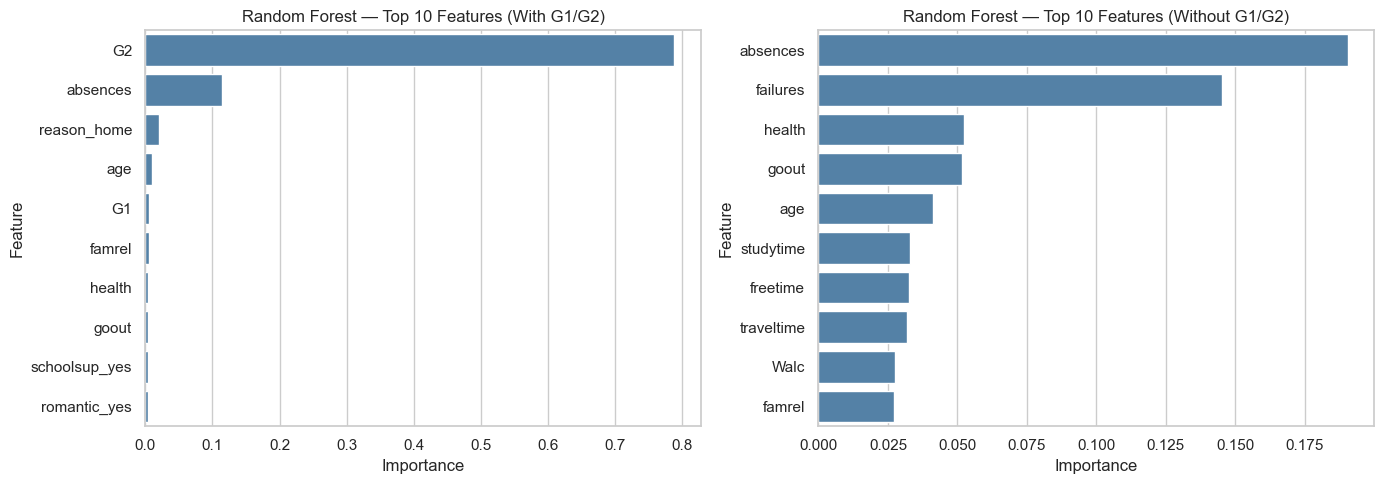

In [28]:
# Top 10 feature importances for both Random Forest models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, X, title in [(axes[0], rf_w, X_with, "With G1/G2"),
                            (axes[1], rf_wo, X_without, "Without G1/G2")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    sns.barplot(x=imp.values, y=imp.index, ax=ax, color="steelblue")
    ax.set_title(f"Random Forest — Top 10 Features ({title})")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

**Observations:**

- **With G1/G2:** `G2` dominates with an importance of about **0.79**. The second-period grade is by far the best
  predictor of the final grade. `G1` ranks low only because it carries almost the same information as `G2` (they are
  highly correlated), so the trees rarely need it once `G2` is used.
- **Without G1/G2:** `absences` (≈ 0.19) and `failures` (≈ 0.15) are the most important, followed by `health`,
  `goout`, `age` and `studytime`. Past failures are a well-known predictor of low grades.
- **Why is `absences` so high?** In this dataset, **all 38 students with G3 = 0 have 0 recorded absences** (the average
  for everyone else is about 6.3). These zeros most likely mean the student dropped out or did not take the final exam,
  not that they attended perfectly. The model uses "0 absences" as a signal for a possible 0 grade, which is a data
  quirk rather than a real behavioral effect.

## 7. Model Performance Visualization: Actual vs. Predicted Grades
Each point is one test-set student. Points on the dashed **y = x** line are perfect predictions; the farther a point is
from the line, the larger the error. Students with an actual G3 of 0 are highlighted in red.

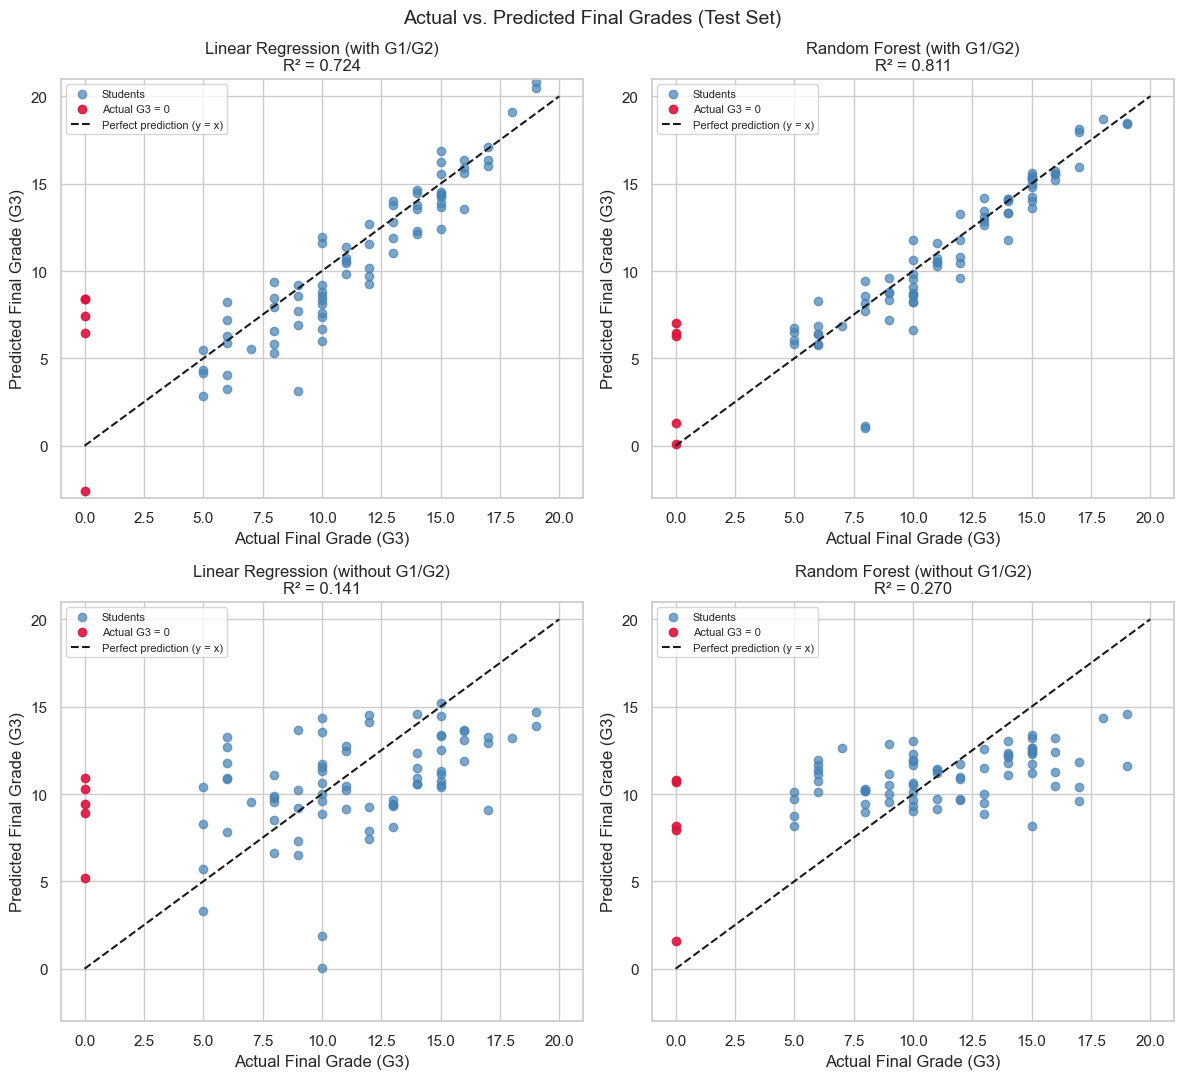

In [29]:
# Actual vs. Predicted: one panel per model/feature-set combination
preds = [("Linear Regression", "with G1/G2", pred_lr_w),
         ("Random Forest", "with G1/G2", pred_rf_w),
         ("Linear Regression", "without G1/G2", pred_lr_wo),
         ("Random Forest", "without G1/G2", pred_rf_wo)]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
zero = (y_test == 0).values  # students whose actual final grade is 0

for ax, (name, feats, pred) in zip(axes.ravel(), preds):
    ax.scatter(y_test[~zero], pred[~zero], alpha=0.7, color="steelblue", label="Students")
    ax.scatter(y_test[zero], pred[zero], alpha=0.9, color="crimson", label="Actual G3 = 0")
    ax.plot([0, 20], [0, 20], "k--", label="Perfect prediction (y = x)")
    ax.set_xlim(-1, 21); ax.set_ylim(-3, 21)
    ax.set_title(f"{name} ({feats})\nR² = {r2_score(y_test, pred):.3f}")
    ax.set_xlabel("Actual Final Grade (G3)")
    ax.set_ylabel("Predicted Final Grade (G3)")
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle("Actual vs. Predicted Final Grades (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**

- **With G1/G2 (top row):** most points lie close to the y = x line, especially for Random Forest, which has a tighter
  cloud than Linear Regression. Linear Regression can also predict impossible values (one prediction is about **−2.5**,
  another slightly above **20**) because it is not bounded to the 0–20 range. Random Forest predictions always stay
  within the range seen in training.
- **Without G1/G2 (bottom row):** predictions cluster around **10–12** regardless of the actual grade. The models
  mostly predict "an average student", so good students are under-predicted and weak students are over-predicted. This
  is what a low R² looks like.
- **Students with G3 = 0 (red):** these are the largest errors in every panel. There are 5 in the test set. Random
  Forest with G1/G2 correctly predicts close to 0 for two of them (one already had G2 = 0; the other had a normal G2 of 7
  but was flagged by other features such as 0 absences), but predicts about 6–7 for the others, whose G1/G2 were normal (7–10) before their final grade dropped to 0.
- **Reverse error:** two students with an actual G3 of 8 are predicted about 1. Both had normal G1/G2 but **0
  absences**, so the model mistook them for dropouts, the same quirk seen in the feature importance.

## 8. Discussion of Results
- **Best model:** Random Forest using all features (including G1/G2): test R² = **0.811**, MSE = **3.87**, CV R² =
  **0.872**. On average its predictions are about **2 grade points** away from the true final grade.
- **Effect of G1/G2:** they are the main source of predictive power. Without them, the best R² is only **0.270**.
  Including them is valid if the goal is to predict the final grade **during** the school year (after the 1st/2nd
  periods). If the goal is to identify at-risk students **before** the year starts, the "without G1/G2" model is the
  realistic one, and its accuracy is limited.
- **Where the model fails:** students who end up with **G3 = 0** (likely dropouts or students who missed the final
  exam). Most of them had normal earlier grades, so no model can foresee the drop to 0. These 38 students (≈10%) cause
  most of the error.
- **Consistency between EDA and modeling:** the correlation analysis (Section 4.4) and the Random Forest importance
  (Section 6.3) agree that G2 dominates and that past failures matter. They disagree on absences (r ≈ 0.03 but high tree
  importance), which is explained by the zero-grade students all having 0 recorded absences.
- **What the metrics mean:** an R² of 0.81 means the model explains about 81% of the variation in final grades. MSE
  weights large errors heavily, so the few G3 = 0 misses noticeably raise it.
- **Test split vs. cross-validation:** the test-set scores differ somewhat from the CV averages (e.g. 0.811 vs 0.872).
  With only 79 test students, one split gives a noisy estimate, so the CV numbers are more reliable.

## 9. Challenges
- **Deciding whether to use G1/G2:** they make prediction much easier but may not be available in a real early-warning
  setting, so we trained and compared both versions.
- **Zero final grades:** 38 students have G3 = 0, likely dropouts rather than real exam scores. They create outliers
  the models cannot predict and a misleading pattern (0 absences ↔ 0 grade).
- **Small dataset:** only 395 students (79 in the test set), so results vary with the train/test split. We added 5-fold
  cross-validation to get a more stable estimate.
- **Many categorical features:** one-hot encoding increased the feature count from 32 to 41 input features.
- **Technical:** a NumPy 2.0 / macOS numerical-library issue caused false warnings in Linear Regression. It was solved by
  pinning NumPy 1.26 (see `requirements.txt`).

## 10. Conclusion
- Random Forest predicted final math grades with **R² = 0.811** (test) / **0.872** (CV) when earlier period grades were
  available, within the 0.6–0.85 range suggested for reasonable performance. It outperformed Linear Regression in both
  feature settings.
- Prior academic performance (**G2**) is by far the strongest predictor. Without it, factors such as **absences**,
  **past failures**, health and social life explain only about **27%** of the variance.
- In practice, the model is useful as a **mid-year** prediction tool; reliable early-warning prediction would need more
  or better data.
- **Future work:** treat G3 = 0 students separately (e.g. a classification model for dropout risk), tune Random Forest
  hyperparameters, and try gradient boosting.

## 11. References
- Cortez, P. & Silva, A. (2008). *Using Data Mining to Predict Secondary School Student Performance.* In Proceedings of
  5th FUture BUsiness TEChnology Conference. Dataset: UCI Machine Learning Repository,
  https://archive.ics.uci.edu/ml/datasets/Student+Performance
- Libraries: pandas, NumPy, matplotlib, seaborn, scikit-learn (Pedregosa et al., 2011)